In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import  DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer



In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv', usecols = ['Age', 'Fare', 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.dropna(inplace = True)

In [5]:
df.shape

(714, 3)

In [6]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [8]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [9]:
clf = DecisionTreeClassifier()

In [10]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)

0.6223776223776224

In [12]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv = 10, scoring = 'accuracy'))

np.float64(0.6316705790297339)

In [24]:
kbin_age = KBinsDiscretizer(n_bins = 15, encode = 'ordinal', strategy = 'quantile')
kbin_fare = KBinsDiscretizer(n_bins = 15, encode = 'ordinal', strategy = 'quantile')

In [25]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [26]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [27]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [28]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', n_bins=15)

In [29]:
trf.named_transformers_['first'].n_bins_

array([15])

In [30]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:, 0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:, 1]
})

In [31]:
output['age_labels'] = pd.cut(x = X_train['Age'], bins = trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x = X_train['Fare'], bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

In [32]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
365,30.0,8.0,7.2500,1.0,"(28.0, 30.0]","(0.0, 7.25]"
155,51.0,13.0,61.3792,12.0,"(47.0, 54.0]","(51.479, 76.292]"
385,18.0,2.0,73.5000,12.0,"(16.0, 19.0]","(51.479, 76.292]"
54,65.0,14.0,61.9792,12.0,"(54.0, 80.0]","(51.479, 76.292]"
175,18.0,2.0,7.8542,2.0,"(16.0, 19.0]","(7.775, 7.896]"


In [33]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2 = clf.predict(X_test_trf)

In [34]:
accuracy_score(y_test, y_pred2)

0.6363636363636364

In [35]:
# cross val score

X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring = 'accuracy'))

np.float64(0.6316901408450704)

In [39]:
def discretize(bins, strategy):
  kbin_age = KBinsDiscretizer(n_bins = bins, encode = 'ordinal', strategy = strategy)
  kbin_fare = KBinsDiscretizer(n_bins = bins, encode = 'ordinal', strategy = strategy)

  trf = ColumnTransformer([
      ('first', kbin_age, [0]),
      ('second', kbin_fare, [1])
  ])

  X_trf = trf.fit_transform(X)
  print(f'Accuracy Score: {np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring = "accuracy"))}')

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(X['Age'])
  plt.title('Before')

  plt.subplot(122)
  plt.hist(X_trf[:, 0], color = 'red')
  plt.title('After')
  plt.show()

  plt.figure(figsize=(14,4))
  plt.subplot(121)
  plt.hist(X['Fare'])
  plt.title('Before')

  plt.subplot(122)
  plt.hist(X_trf[:, 0], color = 'red')
  plt.title('After')
  plt.show()

Accuracy Score: 0.630281690140845


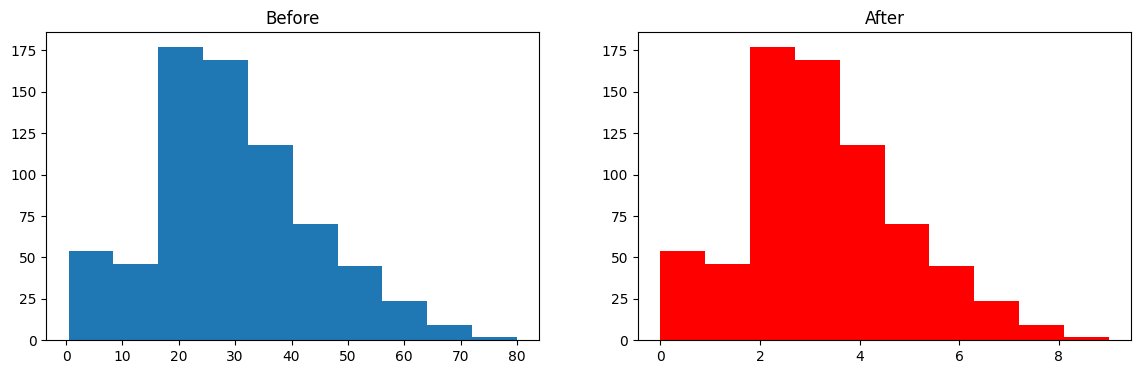

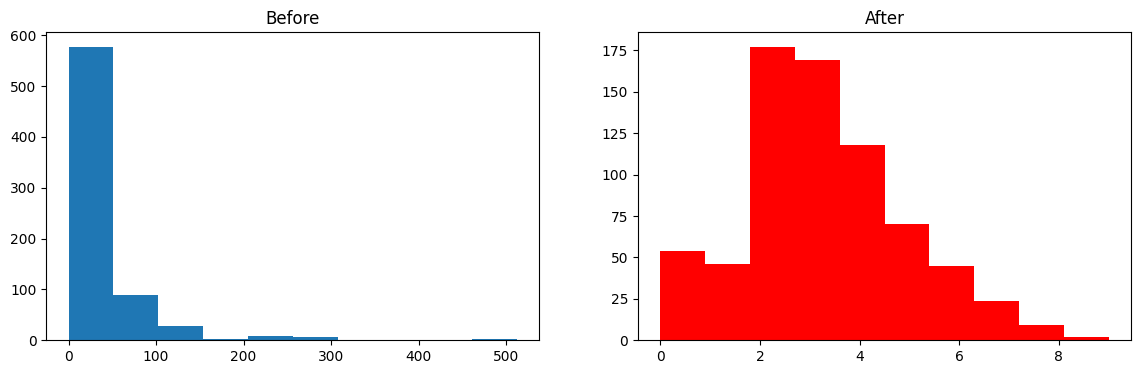

In [40]:
discretize(10, 'uniform')

Accuracy Score: 0.6289123630672926


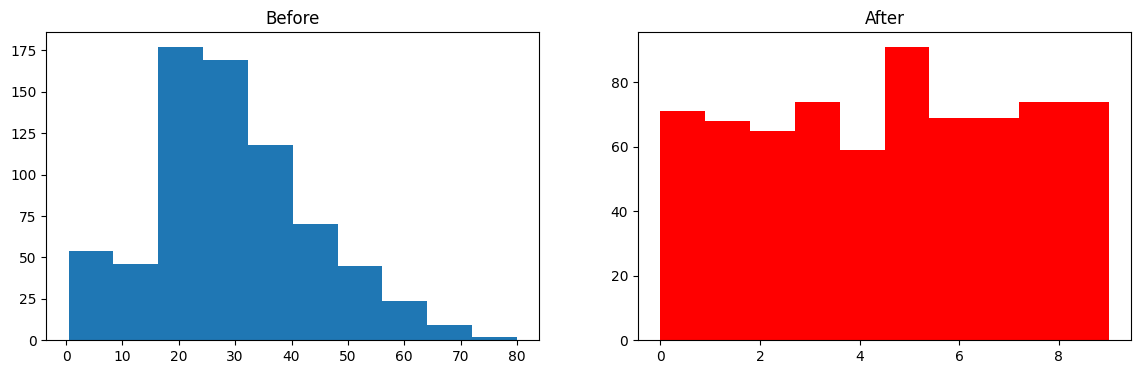

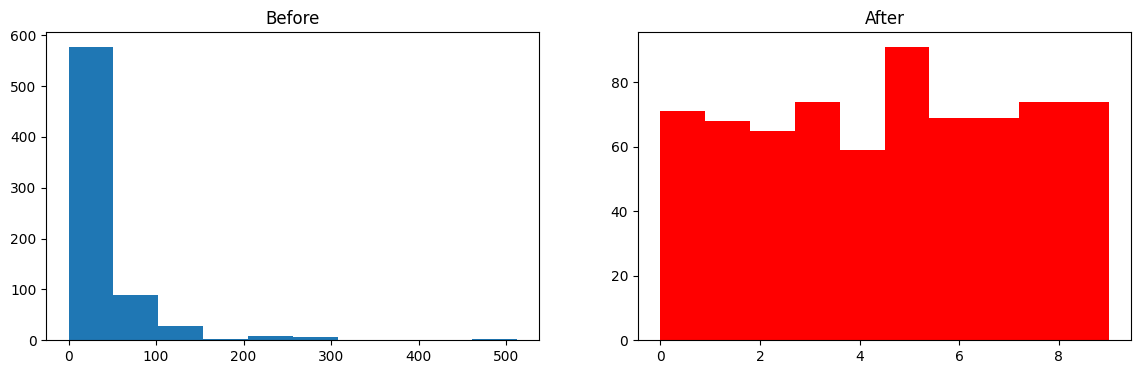

In [41]:
 discretize(10, 'quantile')